In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.text as text
from pylab import *
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.mlab as m
import pandas as pd
#import mpl_toolkits.basemap as bm
import random
from scipy.stats import norm
import statistics
import xarray as xr
import Adtools as Adtools
from datetime import datetime
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib import gridspec
from scipy import stats
from scipy.stats import linregress
from cartopy.util import add_cyclic_point
from mpl_toolkits.basemap import Basemap

import cartopy.feature as cfeature


In [6]:
dirseas5='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/'
dirseas5

dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'
dirfig

dirmon='/nf1/predict/AWH017_ABID_ASPECT/ERA5_daily/tmin/netcdf/frostdays/'
dirmon

dirindices='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/indices/'

In [7]:
direra5='/nf1/predict/AWH017_ABID_ASPECT/ERA5_daily/tmin/netcdf/frostdays/'
direra5
#era5_maap=xr.open_dataset(direra5+'marapr/maapfdall.nc')

era5_maap=xr.open_dataset(direra5+'marapr/maapfdall_update.nc')
era5_maap_1=era5_maap.sel(time=slice(datetime(1983,1,1),datetime(2024,12,31)))
era5_maap_2=era5_maap_1.where((era5_maap_1.latitude>25)&(era5_maap_1.latitude<80),drop=True)
#era5_maap_2

In [8]:
masktopo=xr.open_dataset(dirfig+'finalmask_new_notopsea.nc')
masktopo

maskfo_1=masktopo.where((masktopo.latitude>25)&(masktopo.latitude<88),drop=True)
maskfo_1

<xarray.Dataset> Size: 1MB
Dimensions:    (latitude: 230, longitude: 1437)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 920B 82.5 82.25 82.0 ... 25.75 25.5 25.25
    time       datetime64[ns] 8B 1981-01-01T01:00:00
Data variables:
    topo       (latitude, longitude) float32 1MB nan nan nan nan ... 1.0 1.0 1.0

In [39]:
#country_borders = cfeature.NaturalEarthFeature(category='cultural',name='admin_0_boundary_lines_land',scale='50m',facecolor='none')

In [18]:

era5_maap_2_1=era5_maap_2.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))

climate_mean_ffd_era5=era5_maap_2_1.frost_days_index_per_time_period.groupby('time.month').mean()

mask_data=climate_mean_ffd_era5[0,:,:]*maskfo_1
mask_data

<xarray.Dataset> Size: 1MB
Dimensions:    (longitude: 1437, latitude: 219)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 876B 79.75 79.5 79.25 ... 25.75 25.5 25.25
    time       datetime64[ns] 8B 1981-01-01T01:00:00
    month      int64 8B 4
Data variables:
    topo       (latitude, longitude) float32 1MB nan nan nan nan ... 0.0 0.0 0.0

# Observed Monthly frequency of the frost days

In [37]:
era5_mar=xr.open_dataset(dirmon+'marfrost/new/fdmarall.nc')
era5_mar_1=era5_mar.sel(time=slice(datetime(1983,1,1),datetime(2024,12,31)))
era5_mar_1=era5_mar_1.where((era5_mar_1.latitude>-88)&(era5_mar_1.latitude<88),drop=True)

#era5_mar_1

era5_apr=xr.open_dataset(dirmon+'aprfrost/new/fdaprall.nc')
era5_apr_1=era5_apr.sel(time=slice(datetime(1983,1,1),datetime(2024,12,31)))
era5_apr_1=era5_apr_1.where((era5_apr_1.latitude>-88)&(era5_apr_1.latitude<88),drop=True)
#era5_apr_1

era5_may=xr.open_dataset(dirmon+'mayfrost/new/fdmayall.nc')
era5_may_1=era5_may.sel(time=slice(datetime(1983,1,1),datetime(2023,12,31)))
era5_may_1=era5_may_1.where((era5_may_1.latitude>-88)&(era5_may_1.latitude<88),drop=True)
#era5_may_1


#direra5='/nf1/predict/AWH017_ABID_ASPECT/ERA5_daily/tmin/netcdf/frostdays/'
#direra5


In [34]:
era5_apr_2=era5_apr_1.assign_coords(time= ("time", era5_mar_1.time.data))
#era5_apr_2


In [33]:
era5_maap_march_april=era5_mar_1+era5_apr_2
#era5_maap_march_april


In [40]:
era5_maap_2_1

<xarray.Dataset> Size: 50MB
Dimensions:                           (time: 40, latitude: 219, longitude: 1440)
Coordinates:
  * time                              (time) datetime64[ns] 320B 1983-04-30 ....
  * longitude                         (longitude) float32 6kB 0.0 0.25 ... 359.8
  * latitude                          (latitude) float32 876B 79.75 ... 25.25
Data variables:
    frost_days_index_per_time_period  (time, latitude, longitude) float32 50MB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Aug 01 15:18:06 2025: cdo cat fdmarap_1981.nc fdmarap_1...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

# FFD index for monthly dataset (march, april, may and also for MAAP)

In [43]:
obsmar_freqts=Adtools.data_sub(era5_mar_1.frost_days_index_per_time_period*maskfo_1,0,3.5,41,43) #data, lon_min,lon_max,lat_min,lat_max
obsmar_freqts

obsmar_freqts_1 = obsmar_freqts.weighted(
   np.cos(np.deg2rad(obsmar_freqts.latitude))).mean(('longitude','latitude'))
obsmar_freqts_1

obsapr_freqts=Adtools.data_sub(era5_apr_1.frost_days_index_per_time_period*maskfo_1,0,3.5,41,43) #data, lon_min,lon_max,lat_min,lat_max
obsapr_freqts

obsapr_freqts_1 = obsapr_freqts.weighted(
   np.cos(np.deg2rad(obsapr_freqts.latitude))).mean(('longitude','latitude'))
obsapr_freqts_1

obsmay_freqts=Adtools.data_sub(era5_may_1.frost_days_index_per_time_period*maskfo_1,0,3.5,41,43) #data, lon_min,lon_max,lat_min,lat_max
obsmay_freqts

obsmay_freqts_1 = obsmay_freqts.weighted(
   np.cos(np.deg2rad(obsmay_freqts.latitude))).mean(('longitude','latitude'))
obsmay_freqts_1


obsmaap_freqts=Adtools.data_sub(era5_maap_2.frost_days_index_per_time_period*maskfo_1,0,3.5,41,43) #data, lon_min,lon_max,lat_min,lat_max
obsmaap_freqts

obsmaap_freqts_1 = obsmaap_freqts.weighted(
   np.cos(np.deg2rad(obsmaap_freqts.latitude))).mean(('longitude','latitude'))
#obsmaap_freqts_1


# FFDs based on E-OBS

In [31]:
eobs_index_1=xr.open_dataset(dirindices+'eobs_ffd_marapr.nc')
#eobs_index_1

In [27]:
obsmaap_freqts_1.topo[0:40]
eobs_index_1.topo[0:40]

eobs_index_1.topo[0:40].mean(),obsmaap_freqts_1.topo[0:40].mean()

stats.pearsonr(obsmaap_freqts_1.topo[0:40],eobs_index_1.topo[0:40])


PearsonRResult(statistic=0.9542037045887657, pvalue=1.6318966270444477e-21)

Text(0.0, 1.0, 'b) Frequency of Frost Days (FFD) over Catalonia')

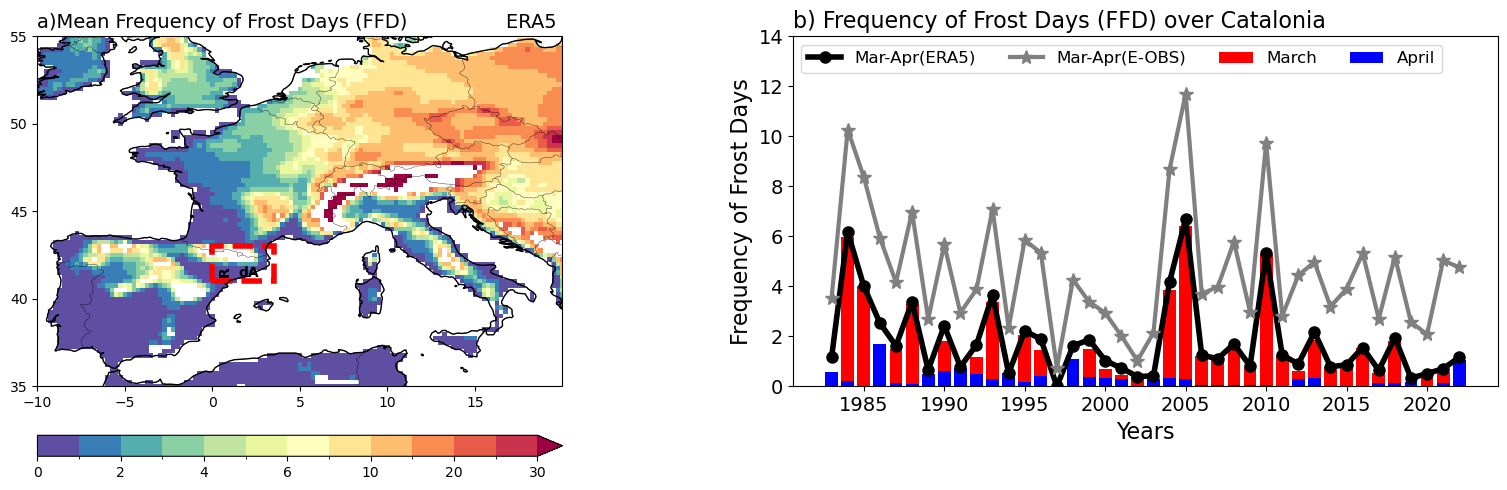

In [30]:
fig = plt.figure(figsize=[20, 10])
fig.patch.set_facecolor('white')
#gs = gridspec.GridSpec(3, 1)

#gs = gridspec.GridSpec(1, 2, height_ratios=height_ratios)
#gs = gridspec.GridSpec(2, 2, width_ratios=[2, 3])

gs = gridspec.GridSpec(2, 2)

# subplot positions
width= 0.65
hight = 0.28;
pos1a = [0.1, 0.75, width, 0.2]
pos1b = [0.1, 0.37, width, hight]
pos1c = [0.79, 0.37, 0.18, hight]
pos1d = [0.1,  0.07, width, 0.2]

ax0= fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

ax0.coastlines(linewidth=0.25)       
ax0.add_feature(cfeature.BORDERS, linewidth=0.25)
ax0.add_feature(cartopy.feature.COASTLINE)


levels=[0,1,2,3,4,5,6,7,10,15,20,25,30]
ax0.set_extent((-10, 20, 35,55),crs=ccrs.PlateCarree())
ax0.set_xticks(np.arange(-10, 20, 5), crs=ccrs.PlateCarree())
ax0.set_yticks(np.arange(35, 56, 5), crs=ccrs.PlateCarree())

out=mask_data.topo.plot(ax=ax0, transform=ccrs.PlateCarree(),levels=levels,cmap='Spectral_r',add_colorbar=False);

#ax.coastlines()
#ax.gridlines()
#plt.text(0.29,41.4, 'Raimat',  color='black', weight='bold', rotation=45)
plt.text(0.284,41.44, 'R', color='black', weight='bold', rotation=90)
plt.text(1.47,41.27, 'dA',  color='black', weight='bold')

#ax0.add_patch( Rectangle((0, 41),1,2,fc ='none',ec ='black',lw = 2,linestyle='dashed'))
ax0.add_patch( Rectangle((0, 41),3.5,2,fc ='none',ec ='red',lw = 4,linestyle='dashed'))


ax0.set_xlabel('')
ax0.set_ylabel('')
ax0.set_title('')

ax0.set_title('a)Mean Frequency of Frost Days (FFD)', loc='left', fontsize=14)# , weight='bold'
ax0.set_title('ERA5 ', loc='right', fontsize=14)# , weight='bold'
cax0 = inset_axes(ax0,
                   width="100%",  # width = 5% of parent_bbox width
                   height="6%",  # height : 50%
                   loc='lower left',
                   bbox_to_anchor=(0, -0.2, 1, 1),
                   bbox_transform=ax0.transAxes,
                   borderpad=0,
                   )

cbar = plt.colorbar(out,cax0,orientation='horizontal')

###########################################
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_ylim([0,14])

x1=np.arange(1983,2023,1)

ax1.xaxis.set_tick_params(labelsize=10)
ax1.yaxis.set_tick_params(labelsize=10)

ax1.plot(x1,obsmaap_freqts_1.topo[0:40],color='black',label='Mar-Apr(ERA5)',linestyle='solid',linewidth=4,marker='o',markersize=8)
ax1.bar(x1, obsmar_freqts_1.topo[0:40],color='red',label='March',linestyle='solid')
ax1.bar(x1, obsapr_freqts_1.topo[0:40],color='blue',label='April',linestyle='solid')
ax1.plot(x1, eobs_index_1.topo[0:40],color='gray',label='Mar-Apr(E-OBS)',linestyle='solid',linewidth=3,marker='*',markersize=10)
#ax[0].bar(np.arange(1983,2023,1), obsmay_freqts_1.topo[0:40],color='green',label='May',linestyle='solid')



#ax.scatter(x1,raimat_data[0:40],color='black',label='Raimat')
ax1.set_ylabel('Frequency of Frost Days', fontsize=16)
ax1.set_xlabel('Years',fontsize=16)

ax1.xaxis.set_tick_params(labelsize=14)
ax1.yaxis.set_tick_params(labelsize=14)
ax1.legend(fontsize=12,loc='upper left',ncols=4)
ax1.set_title('b) Frequency of Frost Days (FFD) over Catalonia', loc='left',fontsize=16)

#########

#plt.savefig(dirfig+"Figure1_final_revised.png",bbox_inches='tight', dpi=300)